In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

In [19]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
depths = range(3, 26)

train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    train_scores.append(train_f1)
    test_scores.append(test_f1)

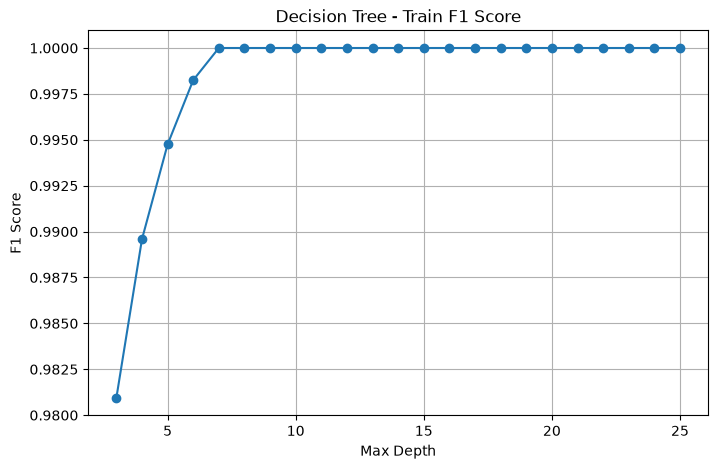

In [22]:
plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, marker='o')
plt.title("Decision Tree - Train F1 Score")
plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

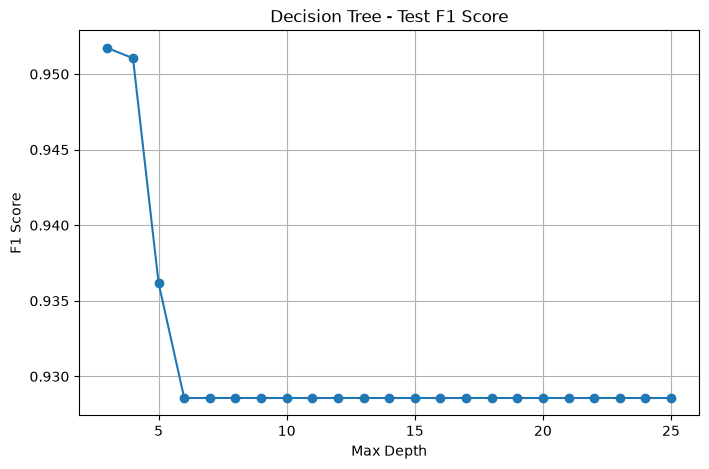

In [23]:
plt.figure(figsize=(8,5))
plt.plot(depths, test_scores, marker='o')
plt.title("Decision Tree - Test F1 Score")
plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.grid(True)
plt.show()

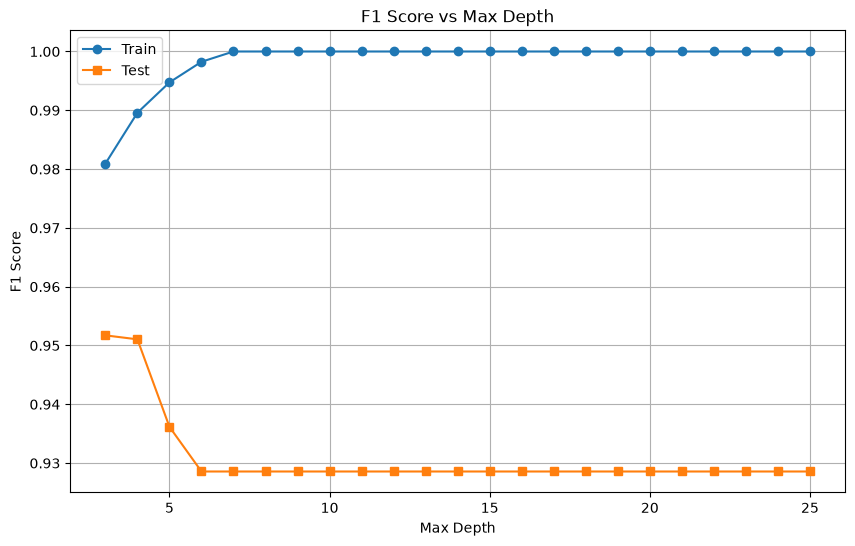

In [24]:
plt.figure(figsize=(10,6))
plt.plot(depths, train_scores, marker='o', label='Train')
plt.plot(depths, test_scores, marker='s', label='Test')
plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Max Depth")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
best_depth = depths[np.argmax(test_scores)]
best_score = max(test_scores)

print(f"Best Max Depth : {best_depth}")
print(f"Best Test F1 Score : {best_score:.4f}")

Best Max Depth : 3
Best Test F1 Score : 0.9517


# Summary

A Decision Tree classifier was trained on the Breast Cancer Wisconsin dataset using different values of max_depth ranging from 3 to 25. The model was evaluated using the F1 score on both the training and testing datasets

The training F1 score increased as the tree depth increased and reached 1.00 for depths greater than or equal to 7. However, the testing F1 score achieved its highest value (0.9517) at a depth of 3 and gradually decreased for larger depths.

This behavior indicates that increasing the tree depth makes the model more complex, allowing it to perfectly fit the training data but reducing its ability to generalize to unseen data. Therefore, the model begins to overfit after the optimal depth.

**Conclusion:**
- Best `max_depth`: **3**
- Best Test F1 Score: **0.9517**
- The model shows **overfitting** for larger values of `max_depth`.
- A smaller tree provides better generalization on this dataset.